# Pulling in Knuth DEMs to prep for IMCORR rock glacier velocity tracking

In [1]:
from pathlib import Path

dem_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/DEMs_Case_Knuth_2024')
ortho_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/Orthos_Case_Knuth_2024')

print("DEMs:")
for f in sorted(dem_dir.glob('*')):
    print(' ', f.name)

print("\nOrthos:")
for f in sorted(ortho_dir.glob('*')):
    print(' ', f.name)

DEMs:
  1954-07-22_2_re-coregistered.tif
  1967-08-03_2_re-coregistered.tif
  1983-09-05_2_re-coregistered.tif
  1989-08-30_3_re-coregistered.tif
  1994-08-25_2_re-coregistered.tif
  2001-08-25_2_re-coregistered.tif

Orthos:
  1967-08-03_ortho.tif
  1979-09-12_sub_cluster_0_ortho.tif
  1979-09-12_sub_cluster_1_ortho.tif
  1979-09-12_sub_cluster_2_ortho.tif
  1983-09-05_ortho.tif
  1983-09-10_ortho.tif
  1983-09-16_sub_cluster_0_ortho.tif
  1983-09-16_sub_cluster_1_ortho.tif
  1989-08-06_ortho.tif
  1989-08-30_ortho.tif
  1989-09-01_ortho.tif
  1989-09-03_ortho.tif
  2001-08-25_ortho.tif
  2002-08-18_ortho.tif


In [2]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import numpy as np
from pathlib import Path

ortho_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/Orthos_Case_Knuth_2024')
out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')
out_dir.mkdir(exist_ok=True)

overlap = (505981.13885482895, 4829065.115635311, 521550.0735170997, 4874858.176136782)
overlap_geom = [box(*overlap).__geo_interface__]

target_res = 1.39  # resample to coarser resolution

for fname, year in [('1967-08-03_ortho.tif', '1967'), ('1983-09-05_ortho.tif', '1983')]:
    with rasterio.open(ortho_dir / fname) as src:
        # Clip to overlap
        out_image, out_transform = mask(src, overlap_geom, crop=True)
        out_meta = src.meta.copy()
        
        out_meta.update({
            'driver': 'GTiff',
            'height': out_image.shape[1],
            'width': out_image.shape[2],
            'transform': out_transform
        })
        
        clipped_path = out_dir / f'{year}_clipped.tif'
        with rasterio.open(clipped_path, 'w', **out_meta) as dest:
            dest.write(out_image)
        print(f"Saved {clipped_path}")

print("Done — now resample both to 1.39m using gdal")

Saved /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_clipped.tif
Saved /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_clipped.tif
Done — now resample both to 1.39m using gdal


In [3]:
import subprocess

for year in ['1967', '1983']:
    inp = out_dir / f'{year}_clipped.tif'
    out = out_dir / f'{year}_clipped_139m.tif'
    subprocess.run([
        'gdal_translate', '-tr', '1.39', '1.39',
        '-r', 'bilinear',
        str(inp), str(out)
    ])
    print(f"Resampled {out}")

Input file size is 19812, 58273
0...10...20...30...40...50...60...70...80...90...100 - done.
Resampled /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_clipped_139m.tif
Input file size is 11181, 32887
0...10...20...30...40...50...60...70...80...90...100 - done.
Resampled /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_clipped_139m.tif


In [4]:
for year in ['1967', '1983']:
    with rasterio.open(out_dir / f'{year}_clipped_139m.tif') as src:
        print(f"{year}: res={src.res}, size={src.width}x{src.height}, bounds={src.bounds}")

1967: res=(1.39, 1.39), size=11201x32945, bounds=BoundingBox(left=505981.13885482895, bottom=4829064.626136783, right=521550.52885482897, top=4874858.176136782)
1983: res=(1.39, 1.39), size=11201x32945, bounds=BoundingBox(left=505980.91613582417, bottom=4829065.580374423, right=521550.3061358242, top=4874859.130374423)


In [5]:
import subprocess

# Use the 1967 bounds as the reference
west, south, east, north = 505981.13885482895, 4829065.115635311, 521550.0735170997, 4874858.176136782

for year in ['1967', '1983']:
    inp = out_dir / f'{year}_clipped.tif'
    out = out_dir / f'{year}_aligned_139m.tif'
    subprocess.run([
        'gdalwarp',
        '-te', str(west), str(south), str(east), str(north),
        '-tr', '1.39', '1.39',
        '-r', 'bilinear',
        '-t_srs', 'EPSG:32612',
        str(inp), str(out)
    ])
    print(f"Done {out}")

# Verify
for year in ['1967', '1983']:
    with rasterio.open(out_dir / f'{year}_aligned_139m.tif') as src:
        print(f"{year}: res={src.res}, size={src.width}x{src.height}, bounds={src.bounds}")

Done /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_aligned_139m.tif
Done /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_aligned_139m.tif
1967: res=(1.39, 1.39), size=11201x32945, bounds=BoundingBox(left=505981.13885482895, bottom=4829064.626136783, right=521550.52885482897, top=4874858.176136782)
1983: res=(1.39, 1.39), size=11201x32945, bounds=BoundingBox(left=505981.13885482895, bottom=4829064.626136783, right=521550.52885482897, top=4874858.176136782)


ERROR 1: Output dataset /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_aligned_139m.tif exists,
but some command line options were provided indicating a new dataset
should be created.  Please delete existing dataset and run again.

ERROR 1: Output dataset /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_aligned_139m.tif exists,
but some command line options were provided indicating a new dataset
should be created.  Please delete existing dataset and run again.



Rock glaciers in scene: 17


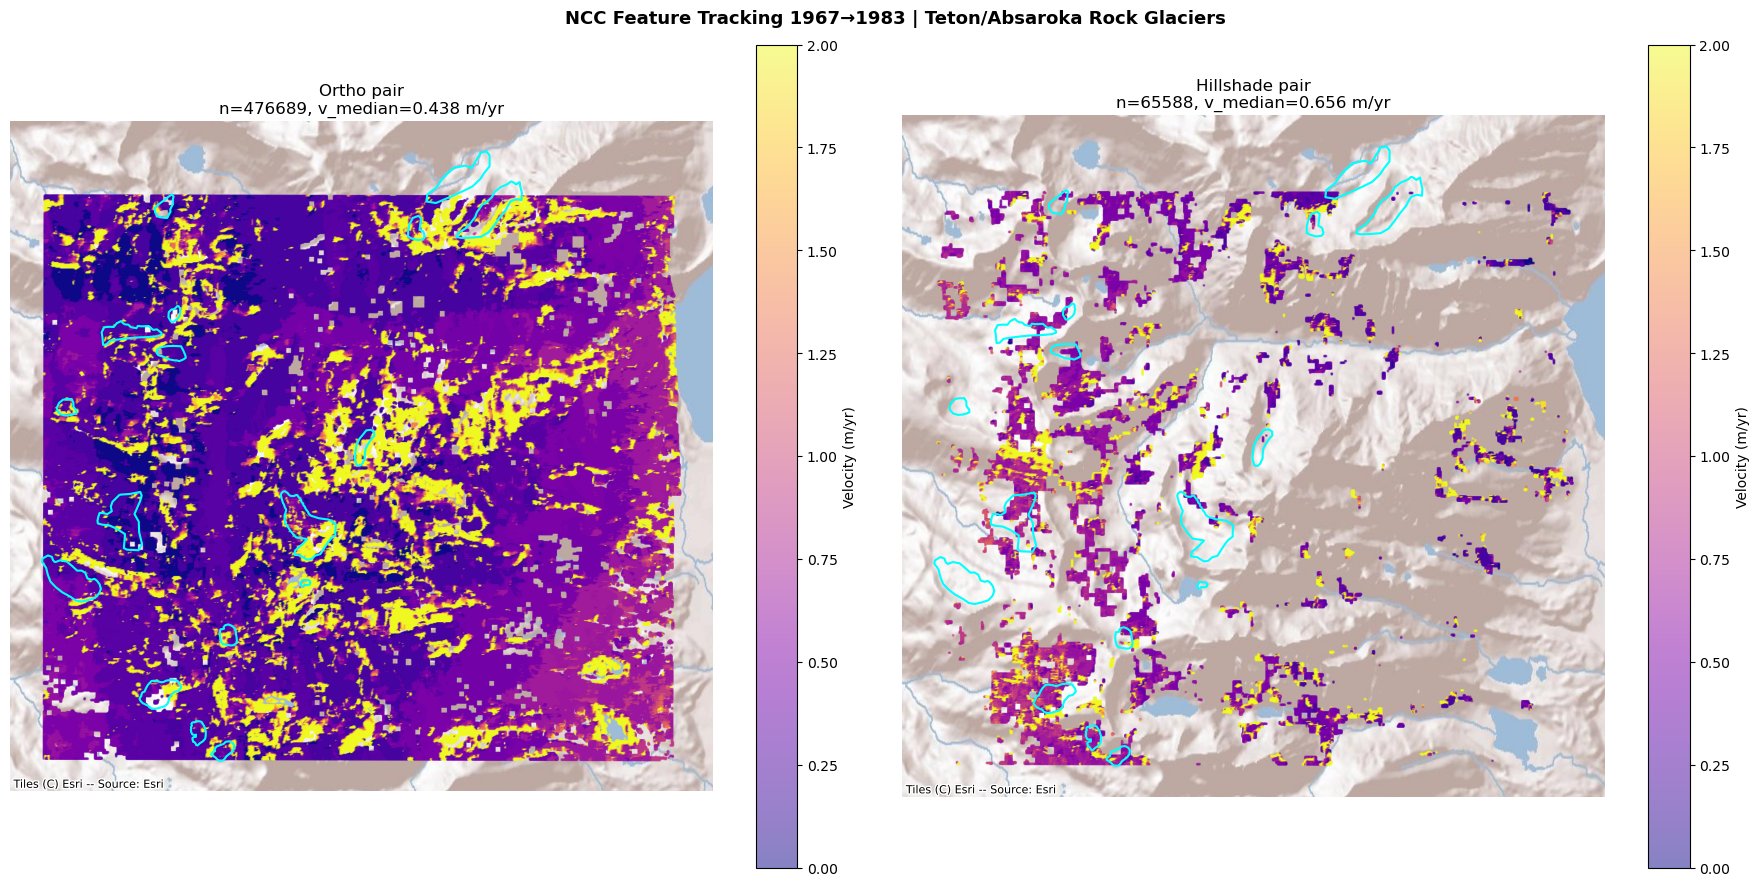

In [7]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from pathlib import Path

out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

# Load PSU ARGI and clip to scene extent
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:32612')

# Scene extent in 32612
from shapely.geometry import box
scene_box = box(509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137)
gdf_rg_scene = gdf_rg[gdf_rg.intersects(scene_box)].to_crs('EPSG:3857')
print(f"Rock glaciers in scene: {len(gdf_rg_scene)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, label, title in zip(axes,
                             ['ortho', 'hillshade'],
                             ['Ortho pair', 'Hillshade pair']):
    gdf = gpd.read_file(out_dir / f'displacement_{label}_1967_1983.shp').to_crs('EPSG:3857')

    sc = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                    c=gdf['v_myr'], cmap='plasma',
                    s=1, alpha=0.5, vmin=0, vmax=2)
    plt.colorbar(sc, ax=ax, label='Velocity (m/yr)')

    # PSU ARGI polygons
    gdf_rg_scene.plot(ax=ax, facecolor='none', edgecolor='cyan',
                      linewidth=1.5, zorder=5)

    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief, zoom=13)
    ax.set_title(f'{title}\nn={len(gdf)}, v_median={gdf["v_myr"].median():.3f} m/yr')
    ax.set_axis_off()

plt.suptitle('NCC Feature Tracking 1967→1983 | Teton/Absaroka Rock Glaciers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'ncc_velocity_map_with_rg.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from pathlib import Path

out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

# Load PSU ARGI and clip to scene extent
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:32612')

# Scene extent in 32612
from shapely.geometry import box
scene_box = box(509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137)
gdf_rg_scene = gdf_rg[gdf_rg.intersects(scene_box)].to_crs('EPSG:3857')
print(f"Rock glaciers in scene: {len(gdf_rg_scene)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, label, title in zip(axes,
                             ['ortho', 'hillshade'],
                             ['Ortho pair', 'Hillshade pair']):
    gdf = gpd.read_file(out_dir / f'displacement_{label}_1967_1983.shp').to_crs('EPSG:3857')

    sc = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                    c=gdf['v_myr'], cmap='plasma',
                    s=1, alpha=0.5, vmin=0, vmax=2)
    plt.colorbar(sc, ax=ax, label='Velocity (m/yr)')

    # PSU ARGI polygons
    gdf_rg_scene.plot(ax=ax, facecolor='none', edgecolor='cyan',
                      linewidth=1.5, zorder=5)

    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief, zoom=13)
    ax.set_title(f'{title}\nn={len(gdf)}, v_median={gdf["v_myr"].median():.3f} m/yr')
    ax.set_axis_off()

plt.suptitle('NCC Feature Tracking 1967→1983 | Teton/Absaroka Rock Glaciers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'ncc_velocity_map_with_rg.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from pathlib import Path
from shapely.geometry import box

out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

# Load and clip PSU ARGI to scene
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:32612')
scene_box = box(509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137)
gdf_rg_scene = gdf_rg[gdf_rg.intersects(scene_box)].copy()
print(f"Rock glaciers in scene: {len(gdf_rg_scene)}")

# Load ortho displacement vectors
gdf_ortho = gpd.read_file(out_dir / 'displacement_ortho_1967_1983.shp').set_crs('EPSG:32612')

# Clip vectors to PSU polygons only
gdf_clipped = gpd.sjoin(gdf_ortho, gdf_rg_scene[['geometry']], 
                         how='inner', predicate='within')
print(f"Vectors within rock glacier polygons: {len(gdf_clipped)}")
print(f"v_median within RGs: {gdf_clipped['v_myr'].median():.3f} m/yr")
print(f"v_mean within RGs:   {gdf_clipped['v_myr'].mean():.3f} m/yr")
print(f"v distribution:\n{gdf_clipped['v_myr'].describe()}")

# Plot
fig, ax = plt.subplots(figsize=(14, 12))

# All ortho vectors as background (grey, low alpha)
gdf_ortho_web = gdf_ortho.to_crs('EPSG:3857')
ax.scatter(gdf_ortho_web.geometry.x, gdf_ortho_web.geometry.y,
           c='grey', s=0.5, alpha=0.1, zorder=2)

# Clipped vectors colored by velocity
gdf_clipped_web = gdf_clipped.to_crs('EPSG:3857')
sc = ax.scatter(gdf_clipped_web.geometry.x, gdf_clipped_web.geometry.y,
                c=gdf_clipped_web['v_myr'], cmap='plasma',
                s=4, alpha=0.8, vmin=0, vmax=2, zorder=4)
plt.colorbar(sc, ax=ax, label='Velocity (m/yr)', shrink=0.6)

# PSU polygons — thick border
gdf_rg_scene.to_crs('EPSG:3857').plot(
    ax=ax, facecolor='none', edgecolor='cyan',
    linewidth=3, zorder=5)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief, zoom=13)
ax.set_title('NCC Ortho Feature Tracking 1967→1983\nVelocity within PSU ARGI Rock Glacier Polygons',
             fontsize=13, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(out_dir / 'ncc_ortho_rg_clipped.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, year in zip(axes, ['1967', '1983']):
    with rasterio.open(out_dir / f'{year}_ortho_hires.tif') as src:
        img = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            img[img == nodata] = np.nan
    
    # Stretch to 2-98 percentile for better contrast
    p2, p98 = np.nanpercentile(img, [2, 98])
    img_stretched = np.clip((img - p2) / (p98 - p2), 0, 1)
    
    ax.imshow(img_stretched, cmap='gray', interpolation='nearest')
    ax.set_title(f'{year} ortho', fontsize=13, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('1967 vs 1983 orthos — visual comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'ortho_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import subprocess

west, south, east, north = 509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137
target_res = 1.39

usable_orthos = [
    ('1967-08-03_ortho.tif',              '1967_0803'),
    ('1979-09-12_sub_cluster_1_ortho.tif','1979_0912_c1'),
    ('1983-09-05_ortho.tif',              '1983_0905'),
    ('1983-09-10_ortho.tif',              '1983_0910'),
    ('1983-09-16_sub_cluster_0_ortho.tif','1983_0916_c0'),
    ('1989-08-06_ortho.tif',              '1989_0806'),
    ('1989-08-30_ortho.tif',              '1989_0830'),
    ('1989-09-03_ortho.tif',              '1989_0903'),
    ('2001-08-25_ortho.tif',              '2001_0825'),
    ('2002-08-18_ortho.tif',              '2002_0818'),
]

print("Aligning all orthos to common grid...")
for fname, label in usable_orthos:
    inp = ortho_dir / fname
    out = out_dir / f'{label}_aligned.tif'
    if out.exists():
        print(f"  {label} already exists, skipping")
        continue
    subprocess.run([
        'gdalwarp',
        '-te', str(west), str(south), str(east), str(north),
        '-tr', str(target_res), str(target_res),
        '-r', 'bilinear',
        '-t_srs', 'EPSG:32612',
        str(inp), str(out)
    ], capture_output=True)
    with rasterio.open(out) as src:
        print(f"  {label}: res={src.res[0]:.2f}m, size={src.width}x{src.height}")

print("\nDone — now visualizing all orthos")

# Visual comparison grid
ncols = 2
nrows = int(np.ceil(len(usable_orthos) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 7))
axes = axes.flatten()

for i, (fname, label) in enumerate(usable_orthos):
    ax = axes[i]
    with rasterio.open(out_dir / f'{label}_aligned.tif') as src:
        img = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            img[img == nodata] = np.nan
    
    p2, p98 = np.nanpercentile(img, [2, 98])
    img_stretched = np.clip((img - p2) / (p98 - p2), 0, 1)
    
    ax.imshow(img_stretched, cmap='gray', interpolation='nearest')
    ax.set_title(f'{label}', fontsize=11, fontweight='bold')
    ax.set_axis_off()

for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.suptitle('All aligned orthos — visual quality check', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'all_orthos_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import subprocess
import rasterio
import numpy as np
from pathlib import Path

dem_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/DEMs_Case_Knuth_2024')
out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

west, south, east, north = 509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137

dems = [
    ('1954-07-22_2_re-coregistered.tif', '1954'),
    ('1967-08-03_2_re-coregistered.tif', '1967'),
    ('1983-09-05_2_re-coregistered.tif', '1983'),
    ('1989-08-30_3_re-coregistered.tif', '1989'),
    ('1994-08-25_2_re-coregistered.tif', '1994'),
    ('2001-08-25_2_re-coregistered.tif', '2001'),
]

# Use finest DEM resolution available — 1967 is 2m, use that as target
target_res = 2.0

print("Clipping, aligning and generating hillshades...")
for fname, year in dems:
    # Clip and align DEM
    dem_out = out_dir / f'{year}_dem_coreg.tif'
    subprocess.run([
        'gdalwarp',
        '-te', str(west), str(south), str(east), str(north),
        '-tr', str(target_res), str(target_res),
        '-r', 'bilinear',
        '-t_srs', 'EPSG:32612',
        str(dem_dir / fname), str(dem_out)
    ], capture_output=True)
    
    # Generate hillshade
    hs_out = out_dir / f'{year}_hillshade_coreg.tif'
    subprocess.run([
        'gdaldem', 'hillshade',
        '-az', '315',
        '-alt', '45', 
        '-z', '2',
        str(dem_out), str(hs_out)
    ], capture_output=True)
    
    with rasterio.open(hs_out) as src:
        print(f"  {year}: res={src.res[0]:.2f}m, size={src.width}x{src.height}, bounds={src.bounds}")

print("\nDone — visualizing all hillshades")

# Visual comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (fname, year) in enumerate(dems):
    ax = axes[i]
    with rasterio.open(out_dir / f'{year}_hillshade_coreg.tif') as src:
        img = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            img[img == nodata] = np.nan
    
    p2, p98 = np.nanpercentile(img, [2, 98])
    img_s = np.clip((img - p2) / (p98 - p2), 0, 1)
    ax.imshow(img_s, cmap='gray', interpolation='nearest')
    ax.set_title(f'{year} hillshade', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Co-registered DEM hillshades 1954-2001', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'hillshades_coreg_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import rasterio
from pathlib import Path
from itertools import combinations

out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

years = ['1954', '1967', '1983', '1989', '1994', '2001']

# Check valid pixel overlap between all pairs
print("Valid pixel overlap between hillshade pairs:")
print(f"{'Pair':>15} {'Valid_ref%':>12} {'Valid_src%':>12} {'Overlap%':>12}")

for y1, y2 in combinations(years, 2):
    with rasterio.open(out_dir / f'{y1}_hillshade_coreg.tif') as src:
        img1 = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            img1[img1 == nodata] = np.nan
    
    with rasterio.open(out_dir / f'{y2}_hillshade_coreg.tif') as src:
        img2 = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            img2[img2 == nodata] = np.nan
    
    valid1 = ~np.isnan(img1)
    valid2 = ~np.isnan(img2)
    overlap = valid1 & valid2
    total = img1.size
    
    print(f"{y1}→{y2}: {valid1.sum()/total*100:>11.1f}% {valid2.sum()/total*100:>11.1f}% {overlap.sum()/total*100:>11.1f}%")

In [ ]:
from scipy.signal import fftconvolve

with rasterio.open(out_dir / '1989_hillshade_coreg.tif') as src:
    ref = src.read(1).astype(np.float32)
    transform = src.transform
    nodata = src.nodata
    if nodata is not None:
        ref[ref == nodata] = np.nan

with rasterio.open(out_dir / '2001_hillshade_coreg.tif') as src:
    search = src.read(1).astype(np.float32)
    nodata = src.nodata
    if nodata is not None:
        search[search == nodata] = np.nan

rows, cols = ref.shape
test_points = [
    (rows//8,   cols//8),
    (rows//8,   cols//2),
    (rows//8,   7*cols//8),
    (rows//2,   cols//8),
    (rows//2,   7*cols//8),
    (7*rows//8, cols//8),
    (7*rows//8, cols//2),
    (7*rows//8, 7*cols//8),
]

def norm(chip):
    m, s = np.mean(chip), np.std(chip)
    return (chip - m) / s if s > 1e-6 else None

print("Co-registration check on 1989→2001 hillshades (stable terrain):")
print(f"{'Point':>12} {'dx_px':>8} {'dy_px':>8} {'dx_m':>8} {'dy_m':>8} {'corr':>8}")

offsets_x, offsets_y = [], []
for r, c in test_points:
    half_s, half_r = 64, 32
    if (r-half_s < 0 or r+half_s >= rows or 
        c-half_s < 0 or c+half_s >= cols):
        continue
    
    ref_c = ref[r-half_r:r+half_r, c-half_r:c+half_r]
    src_c = search[r-half_s:r+half_s, c-half_s:c+half_s]
    
    if np.any(np.isnan(ref_c)) or np.any(np.isnan(src_c)):
        print(f"({r:4d},{c:4d}) -- skipped (nodata)")
        continue
    
    ref_n = norm(ref_c)
    src_n = norm(src_c)
    if ref_n is None or src_n is None:
        continue
    
    corr = fftconvolve(src_n, ref_n[::-1,::-1], mode='valid')
    corr /= (half_r*2)**2
    peak = np.unravel_index(np.argmax(corr), corr.shape)
    peak_val = corr[peak]
    dx_px = peak[1] - corr.shape[1]//2
    dy_px = peak[0] - corr.shape[0]//2
    dx_m = dx_px * abs(transform.a)
    dy_m = dy_px * abs(transform.e)
    offsets_x.append(dx_px)
    offsets_y.append(dy_px)
    print(f"({r:4d},{c:4d}) {dx_px:>8.2f} {dy_px:>8.2f} {dx_m:>8.2f} {dy_m:>8.2f} {peak_val:>8.3f}")

print(f"\nMean offset: dx={np.mean(offsets_x):.2f}px, dy={np.mean(offsets_y):.2f}px")
print(f"Std offset:  dx={np.std(offsets_x):.2f}px, dy={np.std(offsets_y):.2f}px")
print(f"In meters:   dx={np.mean(offsets_x)*abs(transform.a):.2f}m, dy={np.mean(offsets_y)*abs(transform.e):.2f}m")

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
from pathlib import Path
from shapely.geometry import box, mapping
import subprocess

dem_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/DEMs_Case_Knuth_2024')
out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')
out_dir.mkdir(exist_ok=True)

# Load PSU ARGI and clip to DEM study area
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:32612')
study_box = box(509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137)
gdf_rg_scene = gdf_rg[gdf_rg.intersects(study_box)].copy()
print(f"Rock glaciers in scene: {len(gdf_rg_scene)}")

# Buffer rock glaciers by 500m and dissolve to single polygon
buffer_m = 500
gdf_buffered = gdf_rg_scene.copy()
gdf_buffered['geometry'] = gdf_rg_scene.buffer(buffer_m)
combined = gdf_buffered.dissolve()
print(f"Combined buffer area: {combined.area.values[0]/1e6:.2f} km²")

# Save buffer for reference
combined.to_file(out_dir / 'rg_buffer_500m.shp')

# Clip all DEMs to buffered rock glacier extent
dems = [
    ('1954-07-22_2_re-coregistered.tif', '1954'),
    ('1967-08-03_2_re-coregistered.tif', '1967'),
    ('1983-09-05_2_re-coregistered.tif', '1983'),
    ('1989-08-30_3_re-coregistered.tif', '1989'),
    ('1994-08-25_2_re-coregistered.tif', '1994'),
    ('2001-08-25_2_re-coregistered.tif', '2001'),
]

geom = [mapping(combined.geometry.values[0])]

for fname, year in dems:
    inp = dem_dir / fname
    out = out_dir / f'{year}_dem_clipped_rg.tif'
    
    with rasterio.open(inp) as src:
        try:
            out_img, out_transform = mask(src, geom, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                'height': out_img.shape[1],
                'width':  out_img.shape[2],
                'transform': out_transform
            })
            with rasterio.open(out, 'w', **out_meta) as dst:
                dst.write(out_img)
            print(f"{year}: saved {out.name} — size {out_img.shape[2]}x{out_img.shape[1]}")
        except Exception as e:
            print(f"{year}: failed — {e}")

## ugh retrying clip 

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from pathlib import Path
from shapely.geometry import box, mapping

dem_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/DEMs_Case_Knuth_2024')
out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

# Load rock glaciers in scene
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:32612')
scene_box = box(509843.71046617994, 4838422.480658131, 521420.8725671265, 4848334.397376137)
gdf_rg_scene = gdf_rg[gdf_rg.intersects(scene_box)].copy()
print(f"Rock glaciers in scene: {len(gdf_rg_scene)}")

# Buffer by 500m and dissolve to one polygon
gdf_buffered = gdf_rg_scene.copy()
gdf_buffered['geometry'] = gdf_rg_scene.buffer(300) # trying 300 m, dan suggested between 200-500m
combined = gdf_buffered.dissolve()
print(f"Clipping extent: {combined.total_bounds}")
print(f"Clip area: {combined.area.values[0]/1e6:.2f} km²")

geom = [mapping(combined.geometry.values[0])]

dems = [
    ('1954-07-22_2_re-coregistered.tif', '1954'),
    ('1967-08-03_2_re-coregistered.tif', '1967'),
    ('1983-09-05_2_re-coregistered.tif', '1983'),
    ('1989-08-30_3_re-coregistered.tif', '1989'),
    ('1994-08-25_2_re-coregistered.tif', '1994'),
    ('2001-08-25_2_re-coregistered.tif', '2001'),
]

for fname, year in dems:
    inp = dem_dir / fname
    out = out_dir / f'{year}_dem_rg_clipped.tif'
    
    with rasterio.open(inp) as src:
        try:
            out_img, out_transform = mask(src, geom, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                'height':    out_img.shape[1],
                'width':     out_img.shape[2],
                'transform': out_transform
            })
            with rasterio.open(out, 'w', **out_meta) as dst:
                dst.write(out_img)
            print(f"{year}: {out_img.shape[2]}x{out_img.shape[1]} px — saved {out.name}")
        except Exception as e:
            print(f"{year}: skipped — {e}")

Rock glaciers in scene: 17
Clipping extent: [ 509614.91280134 4838219.23201906  518474.57237737 4849296.7685868 ]
Clip area: 16.26 km²
1954: 2539x2920 px — saved 1954_dem_rg_clipped.tif
1967: 4316x5445 px — saved 1967_dem_rg_clipped.tif
1983: 2467x3111 px — saved 1983_dem_rg_clipped.tif
1989: 686x864 px — saved 1989_dem_rg_clipped.tif
1994: 1121x1415 px — saved 1994_dem_rg_clipped.tif
2001: 993x1250 px — saved 2001_dem_rg_clipped.tif


In [11]:
import subprocess
import rasterio

for year in ['1954', '1967', '1983', '1989', '1994', '2001']:
    inp = out_dir / f'{year}_dem_rg_clipped.tif'
    out_hs = out_dir / f'{year}_hillshade_rg_clipped.tif'
    subprocess.run([
        'gdaldem', 'hillshade',
        '-az', '315',
        '-alt', '45',
        '-z', '2',
        str(inp), str(out_hs)
    ], capture_output=True)
    
    with rasterio.open(out_hs) as src:
        print(f"{year}: {src.width}x{src.height} px, res={src.res[0]:.2f}m")

1954: 2539x2920 px, res=3.40m
1967: 4316x5445 px, res=2.00m
1983: 2467x3111 px, res=3.50m
1989: 686x864 px, res=12.60m
1994: 1121x1415 px, res=7.70m
2001: 993x1250 px, res=8.70m


In [13]:
import subprocess
import rasterio

# Resample 1967 (2m) down to match 1983 (3.5m)
target_res = 3.5

for year in ['1967', '1983']:
    inp = out_dir / f'{year}_hillshade_rg_clipped.tif'
    out = out_dir / f'{year}_hillshade_1967_1983_35m.tif'
    
    subprocess.run([
        'gdalwarp',
        '-tr', str(target_res), str(target_res),
        '-r', 'average',  # average is better than bilinear for downsampling
        '-t_srs', 'EPSG:32612',
        str(inp), str(out)
    ], capture_output=True)
    
    with rasterio.open(out) as src:
        print(f"{year}: {src.width}x{src.height} px, res={src.res[0]:.2f}m")
        print(f"  saved → {out}")

print("\nFiles ready for SAGA:")
print(f"  {out_dir / '1967_hillshade_1967_1983_35m.tif'}")
print(f"  {out_dir / '1983_hillshade_1967_1983_35m.tif'}")

1967: 2466x3111 px, res=3.50m
  saved → /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_hillshade_1967_1983_35m.tif
1983: 2467x3111 px, res=3.50m
  saved → /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_hillshade_1967_1983_35m.tif

Files ready for SAGA:
  /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_hillshade_1967_1983_35m.tif
  /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_hillshade_1967_1983_35m.tif


In [14]:
import subprocess
import rasterio

# Get exact bounds from 1983 (coarser, use as reference grid)
with rasterio.open(out_dir / '1983_hillshade_rg_clipped.tif') as src:
    b = src.bounds
    res = src.res[0]

west, south, east, north = b.left, b.bottom, b.right, b.top
print(f"Reference grid: res={res}m, bounds={b}")

for year in ['1967', '1983']:
    inp = out_dir / f'{year}_hillshade_rg_clipped.tif'
    out = out_dir / f'{year}_hillshade_imcorr_ready.tif'
    subprocess.run([
        'gdalwarp',
        '-te', str(west), str(south), str(east), str(north),
        '-tr', str(res), str(res),
        '-r', 'average',
        '-t_srs', 'EPSG:32612',
        '-overwrite',
        str(inp), str(out)
    ])
    with rasterio.open(out) as src:
        print(f"{year}: {src.width}x{src.height} px, res={src.res[0]:.2f}m, bounds={src.bounds}")

print("\nFiles ready for SAGA:")
print(f"  {out_dir / '1967_hillshade_imcorr_ready.tif'}")
print(f"  {out_dir / '1983_hillshade_imcorr_ready.tif'}")

Reference grid: res=3.5m, bounds=BoundingBox(left=509842.8725671265, bottom=4838409.552289365, right=518477.3725671265, top=4849298.052289365)
Creating output file that is 2467P x 3111L.
Using internal nodata values (e.g. 0) for image /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_hillshade_rg_clipped.tif.
Copying nodata values from source /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_hillshade_rg_clipped.tif to destination /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_hillshade_imcorr_ready.tif.
Processing /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1967_hillshade_rg_clipped.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
1967: 2467x3111 px, res=3.50m, bounds=BoundingBox(left=509842.8725671265, bottom=4838409.552289365, right=518477.3725671265, top=4849298.052289365)
Creating output file that is 2467P x 3111L.
Using internal nodata values (e.g. 0) for image /Users/milliespencer/WUS_rock_glaciers/teton_imcorr/1983_hillsha